In [1]:
include(joinpath(dirname(Base.active_project()), "src", "AutoSpider.jl"))
using .AutoSpider, HDF5

include(joinpath(AutoSpider.FUNCTION_PATH, "VizUtils.jl"))
using .VizUtils

In [2]:
using Statistics

function find_err_coeffs(dict::AbstractDict, s::Vector{String}=["h∂^2u/∂t^2", "h∂^2v/∂t^2", "h∂^2Bx/∂t^2", "h∂^2By/∂t^2"])::Vector{Float64}
    a::Vector{Float64} = zeros(length(s))

    j::Int64 = 1
    for i::Int64 ∈ 1:5
        idx = findfirst(x -> x ∈ s, dict[i]["label"])
        if isnothing(idx)
            continue
        end

        a[j] = dict[i]["coeff"][idx]
        j += 1
    end

    return a
end

find_err_coeffs (generic function with 2 methods)

In [4]:
dts::Vector{Float64} = round.(LinRange(0.001, 0.005, 9), sigdigits=5)

results::Vector = Vector{Union{Missing, Dict}}(missing, 9)
for i ∈ eachindex(dts)
    results[i] = AutoSpider.auto_spider("ieuler/data-" * repr(dts[i]) * ".hdf5", "compare/ieuler/settings-" * repr(dts[i]) * ".json")
end

results

∂u/∂x + ∂v/∂y = 0
∂u/∂t + ∂u^2/∂x + ∂uv/∂y - 0.016∂^2u/∂x^2 - 0.016∂^2u/∂y^2 + ∂P/∂x - ∂Bx^2/∂x - ∂BxBy/∂y - 0.0h∂^2u/∂t^2 - cos(y) = 0
∂v/∂t + ∂uv/∂x + ∂v^2/∂y - 0.016∂^2v/∂x^2 - 0.016∂^2v/∂y^2 + ∂P/∂y - ∂By^2/∂y - ∂BxBy/∂x - 0.0h∂^2v/∂t^2 + cos(x) = 0
∂Bx/∂t - 0.001h∂^2Bx/∂t^2 - 0.016∂^2Bx/∂x^2 - 0.016∂^2Bx/∂y^2 - ∂uBy/∂y + ∂vBx/∂y = 0
∂By/∂t - 0.016∂^2By/∂x^2 - 0.016∂^2By/∂y^2 + ∂uBy/∂x - ∂vBx/∂x = 0
∂u/∂x + ∂v/∂y = 0
∂v/∂t + ∂uv/∂x + ∂v^2/∂y - 0.016∂^2v/∂x^2 - 0.016∂^2v/∂y^2 + ∂P/∂y - ∂By^2/∂y - ∂BxBy/∂x - 0.001h∂^2v/∂t^2 + cos(x) = 0
∂u/∂t + ∂u^2/∂x + ∂uv/∂y - 0.016∂^2u/∂x^2 - 0.016∂^2u/∂y^2 + ∂P/∂x - ∂Bx^2/∂x - ∂BxBy/∂y - 0.001h∂^2u/∂t^2 - cos(y) = 0
∂Bx/∂t - 0.001h∂^2Bx/∂t^2 - 0.016∂^2Bx/∂x^2 - 0.016∂^2Bx/∂y^2 - ∂uBy/∂y + ∂vBx/∂y = 0
∂By/∂t - 0.001h∂^2By/∂t^2 - 0.016∂^2By/∂x^2 - 0.016∂^2By/∂y^2 + ∂uBy/∂x - ∂vBx/∂x = 0
∂u/∂x + ∂v/∂y = 0
∂By/∂t - 0.001h∂^2By/∂t^2 - 0.016∂^2By/∂x^2 - 0.016∂^2By/∂y^2 + ∂uBy/∂x - ∂vBx/∂x = 0
∂u/∂t + ∂u^2/∂x + ∂uv/∂y - 0.016∂^2u/∂x^2 - 0.016∂^2u/∂y^2 

9-element Vector{Union{Missing, Dict}}:
 Dict{Int64, Dict{String, Any}}(5 => Dict("label" => ["∂By/∂t", "∂^2By/∂x^2", "∂^2By/∂y^2", "∂uBy/∂x", "∂vBx/∂x"], "cs" => [0.0 0.0 … 0.0008862692659115787 0.0008890619106074542; 0.0 0.0 … 0.0004476319158137371 0.0004490889111661391; … ; 0.0 0.0 … -1.5288213650559555e-5 -1.4823176931908549e-5; 0.0 0.0 … -6.462833527270377e-5 -6.259796069622305e-5], "k" => 5, "equation" => "∂By/∂t - 0.016∂^2By/∂x^2 - 0.016∂^2By/∂y^2 + ∂uBy/∂x - ∂vBx/∂x = 0", "G" => [-0.3584692782561788 -0.18655036399835473 … 0.03648020352266336 0.044714957347332746; 0.20127195280991877 -0.1802817926497866 … -0.17068809248156658 0.26707202570530086; … ; -0.11854419239063416 1.0583437252426584 … 0.05259114772771426 -0.062738317111771; -0.06351414178661495 -0.555038494661537 … 0.06482386979798593 0.2292149784585469], "coeff" => [0.9991596323679525, -0.015812059369550588, -0.015639376112408617, 0.9988273248101315, -1.0], "residuals" => [0.15820154309981754, 0.12062146558130346, 0.0394

In [5]:
avals::Matrix{Float64} = zeros((9,4))
s = ["h∂^2u/∂t^2", "h∂^2v/∂t^2", "h∂^2Bx/∂t^2", "h∂^2By/∂t^2"]

for i ∈ eachindex(results)
    for j ∈ eachindex(s)
        avals[i,j] = find_err_coeffs(results[i], [s[j]])[1]
    end
end

avals

9×4 Matrix{Float64}:
 -0.000493217  -0.000393255  -0.000851709   0.0
 -0.000676317  -0.000854642  -0.000724879  -0.000748173
 -0.000981678  -0.000971385  -0.000952201  -0.00101177
 -0.00126411   -0.00122091   -0.00127857   -0.00126495
 -0.00150629   -0.00151883   -0.00149945   -0.00149081
 -0.00176005   -0.00176254   -0.00173938   -0.00174766
 -0.00201723   -0.00202675   -0.00200154   -0.00199676
 -0.00229577   -0.00226288   -0.00224141   -0.00223912
 -0.00250612   -0.00253567   -0.00250346   -0.00249457

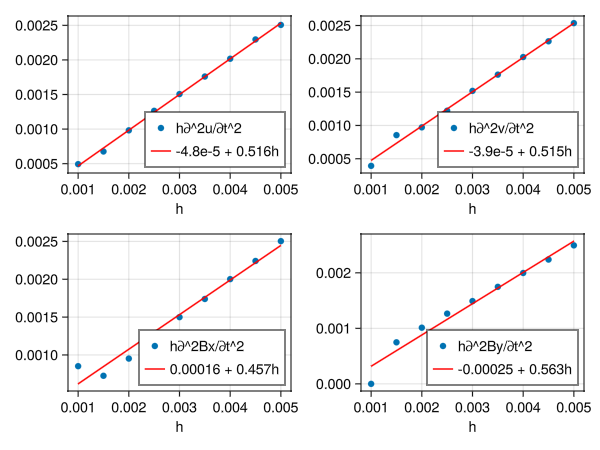

In [24]:
using GLMakie, GLM

f = Figure()
ax = Vector{Union{Missing, Axis}}(missing, 4)
ax[1] = Axis(f[1,1], xlabel="h")
ax[2] = Axis(f[1,2], xlabel="h")
ax[3] = Axis(f[2,1], xlabel="h")
ax[4] = Axis(f[2,2], xlabel="h")

for i ∈ 1:4
    X::Vector{Float64} = dts
    Y::Vector{Float64} = [abs(avals[j,i])  for j ∈ 1:9]
    scatter!(ax[i], X, Y, label=s[i])

    model = lm(@formula(Y ~ X), (;Y, X))
    cf = coef(model)
    lines!(ax[i], X, cf[1] .+ cf[2]*X, color="red", label=(repr(round(cf[1], sigdigits=2)) * " + " * repr(round(cf[2], sigdigits=3)) * "h"))
end

for i ∈ 1:4
    axislegend(ax[i], position = :rb)
end
f

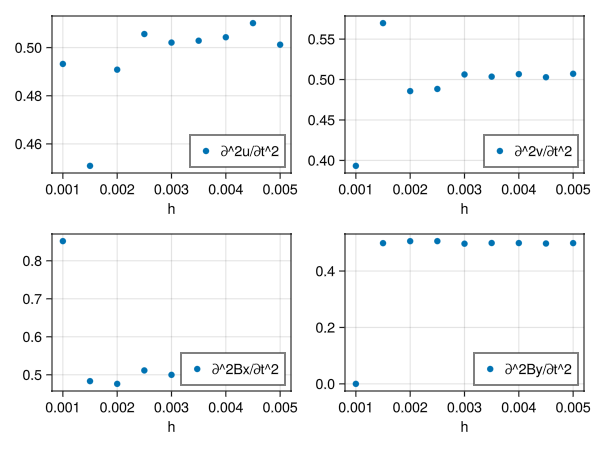

In [25]:
f = Figure()
ax = Vector{Union{Missing, Axis}}(missing, 4)
ax[1] = Axis(f[1,1], xlabel="h")
ax[2] = Axis(f[1,2], xlabel="h")
ax[3] = Axis(f[2,1], xlabel="h")
ax[4] = Axis(f[2,2], xlabel="h")

for i ∈ 1:4
    scatter!(ax[i], dts, [abs(avals[j,i]) ./ dts[j]  for j ∈ 1:9], label=s[i][2:end])
end

for i ∈ 1:4
    axislegend(ax[i], position = :rb)
end
f

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

Y ~ 1 + X

Coefficients:
────────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error       t  Pr(>|t|)    Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────
(Intercept)  -4.32008e-5  1.56808e-5   -2.76    0.0283  -8.02799e-5  -6.12169e-6
X             0.512864    0.00480123  106.82    <1e-11   0.501511     0.524217
────────────────────────────────────────────────────────────────────────────────

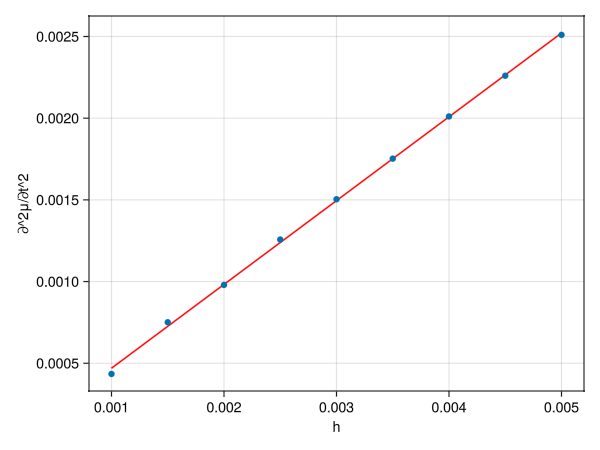

In [27]:
f = Figure()
ax = Axis(f[1,1], xlabel="h", ylabel="∂^2μ/∂t^2")

X::Vector{Float64} = dts
Y::Vector{Float64} = [abs(mean(avals[j,:]))  for j ∈ 1:9]

model = lm(@formula(Y ~ X), (;Y, X))
cf = coef(model)

display(model)

lines!(ax, X, cf[1] .+ cf[2]*X, color="red")
scatter!(ax, X, Y)

f

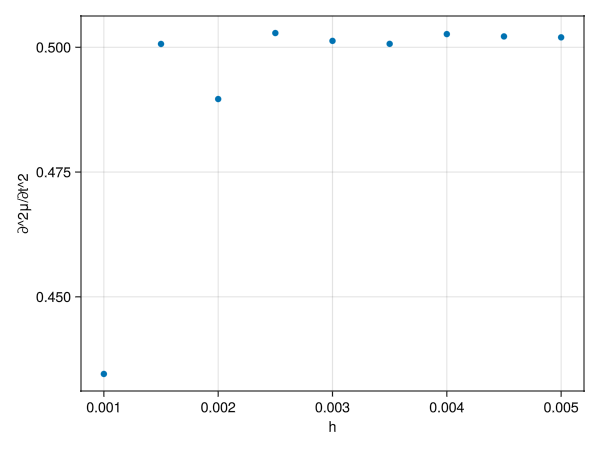

In [100]:
f = Figure()
ax = Axis(f[1,1], xlabel="h", ylabel="∂^2μ/∂t^2")
scatter!(ax, dts, [abs(mean(avals[j,:])) / dts[j] for j ∈ 1:9])
f